In [1]:
import sys
sys.path.append('..')

import numpy as np
import torch
from tqdm import tqdm

%matplotlib inline
import matplotlib.pyplot as plt


In [2]:
def marginals(joint: torch.Tensor):
    # split joint samples into marginals X,Y
    dim = joint.shape[-1]
    mask = torch.zeros(dim, dtype=torch.bool, device=joint.device)
    mask[dim//2+1:] = True
    mask[1] = True
    return joint[:,~mask], joint[:,mask]


# exp config
device = torch.device('cuda:0')
hdgm_dim = 40
n_tests = 100
n_test_samples = 1000
pretrained_path = "../exp/pretrained/deepkernel/hdgm40/mlp_small/best.pt"


In [8]:
from torch.utils.data import DataLoader, Dataset
from data.toy import BlobHD, HDGM
import metrics

#dataset = HDGM(size=n_tests*n_test_samples, dim=hdgm_dim)
dataset = BlobHD(size=n_tests*n_test_samples,
                 dim=hdgm_dim,
                 var=1,
                 seed=0)
dataloader = DataLoader(dataset=dataset,
                        batch_size=n_test_samples,
                        shuffle=True,
                        drop_last=True,
                        num_workers=0,
                        pin_memory=True)


'\nclass HDGM(Dataset):\n    \n    def __init__(self, n_samples: int, dim: int):\n        super().__init__()\n        assert dim>=2\n        self.dim = dim\n\n        self.cov1 = np.eye(dim)\n        self.cov2 = np.eye(dim)\n        self.cov1[0,1] = self.cov1[1,0] = 0.5\n        self.cov2[0,1] = self.cov2[1,0] = -0.5\n        self.L1 = np.linalg.cholesky(self.cov1)\n        self.L2 = np.linalg.cholesky(self.cov2)\n\n        self.data = self.sample((n_samples,))\n\n    def __len__(self):\n        return len(self.data)\n\n    def __getitem__(self, idx):\n        return torch.from_numpy(self.data[idx]).float()\n\n    def sample(self, size):\n        eps = np.random.normal(size=size+(self.dim,))   # (N,D)\n        data = np.empty_like(eps)\n\n        mix_id = np.random.randint(2, size=size)    # (N,)\n        data[mix_id==0] = eps[mix_id==0] @ self.L1.T\n        data[mix_id==1] = eps[mix_id==1] @ self.L2.T\n        return data\n'

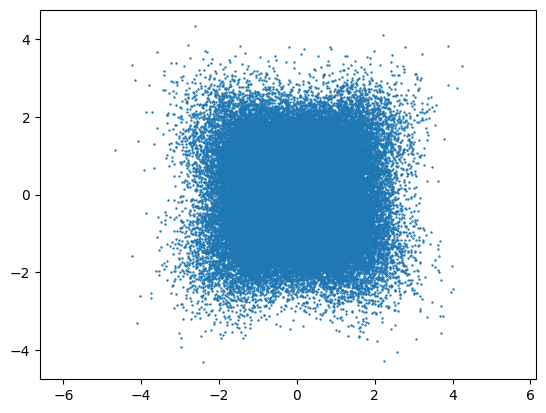

In [9]:
joint = torch.from_numpy(dataset.data)
X,Y = marginals(joint)
X = X.numpy()
Y = Y.numpy()
plt.scatter(X[:,0], Y[:,0], s=0.5)
plt.axis('equal')

dataloader = DataLoader(dataset=dataset,
                        batch_size=n_test_samples,
                        shuffle=True,
                        drop_last=True,
                        num_workers=0,
                        pin_memory=True)


In [10]:
from model.mlp import MLP
from kernel import Gaussian, DeepKernel
from utils import utils

# Define model
featurizer = MLP(features=[20, 60, 60, 60],
                 activation='ReLU')             # NOTE: this should be ReLU for HDGM40 (even though config says ELU)
feature_kernel = Gaussian(trainable=True)
smoothing_kernel = Gaussian(trainable=True)
model = DeepKernel(featurizer, feature_kernel, smoothing_kernel, eps=0.01, trainable=True)
model = model.to(device)

# load model
utils.load_checkpoint(pretrained_path, model, device=device)
model.eval()
k = model
l = model

print('feature_kernel_bandwidth:', model.feature_kernel.bandwidth)
print('smoothing_kernel_bandwidth',model.smoothing_kernel.bandwidth)
print('deepkernel_eps:', model.eps)
print(model.featurizer.net[0].linear.weight)


feature_kernel_bandwidth: tensor([0.0735], device='cuda:0', grad_fn=<ExpBackward0>)
smoothing_kernel_bandwidth tensor([0.9991], device='cuda:0', grad_fn=<ExpBackward0>)
deepkernel_eps: tensor([0.0055], device='cuda:0', grad_fn=<SigmoidBackward0>)
Parameter containing:
tensor([[ 0.0483, -0.1649,  0.1435,  ..., -0.1851, -0.1606,  0.1628],
        [-0.2771, -0.2599,  0.1039,  ..., -0.0764, -0.3733, -0.1745],
        [-0.2195,  0.0120,  0.0827,  ...,  0.0981, -0.0477, -0.2105],
        ...,
        [-0.0927,  0.0748,  0.0264,  ..., -0.0822, -0.2385, -0.0799],
        [ 0.1472,  0.0804,  0.1924,  ..., -0.2864,  0.2064,  0.0181],
        [ 0.2512,  0.0405,  0.1862,  ..., -0.1200, -0.0284,  0.0078]],
       device='cuda:0', requires_grad=True)


In [11]:
with torch.no_grad():
    n_reject = 0
    for batch in (pbar:=tqdm(dataloader)):
        joint = batch.to(device)
        X,Y = marginals(joint)
        hsic, _, p_value, _ = metrics.hsic.permutation_test(k,l,X,Y)
        if p_value < 0.05:
            n_reject += 1
        pbar.set_description(f"[p-value: {p_value:.4f}]")


[p-value: 0.2940]: 100%|██████████| 100/100 [00:28<00:00,  3.45it/s]


In [12]:
power = n_reject/n_tests
print('power_1000:', power)


power_1000: 0.66
